#Sales Forecasting System

**Domain:** Retail / FP&A -- Time Series

**Dataset:** Store Item Demand Forecasting -- https://www.kaggle.com/competitions/demand-forecasting-kernels-only

**Skills:** Time-Series Analysis, Forecasting, Seasonality, Feature Engineering, Model Evaluation

**Tools:** Python, Pandas, XGBoost, Scikit-learn, Matplotlib

---

### Problem Statement
A retail chain's finance team needs a rolling sales forecast to plan inventory and staffing. Naive 'last month = next month' assumptions consistently miss seasonal spikes, so they need a model that accounts for trend, seasonality, and promotions.

In [1]:
!pip install -q kagglehub

### Setup

In [2]:
import pandas as pd
import numpy as np
import os
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
# ---- dataset loading helper: tries kaggle first, never crashes the notebook ----
# kagglehub comes pre-installed on google colab, but just in case it's missing
# (running locally, older colab image etc) we try to pip install it quietly first
try:
    import kagglehub
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "kagglehub", "--break-system-packages"], check=False)
    try:
        import kagglehub
    except ImportError:
        kagglehub = None  # still not available, load_dataset_safe below will just use fake data

# a lot of the kaggle datasets in this project series randomly fail to download
# (auth issues, dataset moved, rate limit, no internet on the runtime, kagglehub missing etc)
# so instead of letting the whole notebook die, we fall back to a small fake dataset
# that has the exact same columns, so every line of code below still works
def load_dataset_safe(kaggle_handle, csv_name, synthetic_fn, n_rows=1500):
    if kagglehub is None:
        print("kagglehub isn't available, using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)
    try:
        path = kagglehub.dataset_download(kaggle_handle)
        full_path = os.path.join(path, csv_name)

        # the exact filename/path we expect doesn't always match what kaggle actually gives us
        # (nested folders, versioned paths, slightly different casing) -- if our guess isn't
        # there, look for any CSV in the download instead of giving up and going to synthetic data
        if not os.path.exists(full_path):
            csv_candidates = []
            for root, _dirs, files in os.walk(path):
                for fname in files:
                    if fname.lower().endswith('.csv'):
                        csv_candidates.append(os.path.join(root, fname))
            if csv_candidates:
                csv_candidates.sort(key=lambda p: 0 if csv_name.lower() in p.lower() else 1)
                full_path = csv_candidates[0]
                print(f"expected file not found at that exact path, using closest match instead: {os.path.basename(full_path)}")
            else:
                raise FileNotFoundError(f"no CSV files found anywhere in the downloaded dataset at {path}")

        # not every kaggle CSV is UTF-8 -- try that first, then fall back to latin-1/ISO-8859-1
        # instead of treating any decode error as a total failure and going to synthetic data
        try:
            df = pd.read_csv(full_path)
        except UnicodeDecodeError:
            df = pd.read_csv(full_path, encoding='ISO-8859-1')

        print(f"loaded real dataset from kaggle, {len(df)} rows")
        return df
    except Exception as e:
        print("could not download from kaggle (", e, ") - using synthetic sample data instead so the rest of the code still runs")
        return synthetic_fn(n_rows)


def make_fake_superstore_sales(n_rows=3000):
    np.random.seed(5)
    dates = pd.date_range('2022-01-01', periods=700)
    cats = ['Furniture', 'Office Supplies', 'Technology']
    regions = ['East', 'West', 'Central', 'South']
    rows = []
    for cat in cats:
        for region in regions:
            base = np.random.uniform(50, 200)
            for d in dates:
                seasonal = 20 * np.sin(d.dayofyear / 365 * 2 * np.pi)
                weekend_bump = 15 if d.dayofweek >= 5 else 0
                noise = np.random.normal(0, 15)
                sales = max(0, base + seasonal + weekend_bump + noise)
                rows.append({'Order Date': d, 'Category': cat, 'Region': region, 'Sales': round(sales, 2)})
    return pd.DataFrame(rows).sample(min(n_rows, len(rows)), random_state=1).sort_values('Order Date')

### Step 1: Load Data -- Note: The Original "Store Item Demand Forecasting Challenge" On Kaggle Is A

In [3]:
# 1. LOAD DATA -- note: the original "Store Item Demand Forecasting Challenge" on kaggle is a
# competition, not a plain dataset, so kagglehub can't auto-download it (needs contest sign-in).
# using the Superstore sales dataset instead, grouping by Category+Region like store/item pairs
df = load_dataset_safe('vivek468/superstore-dataset-final', 'Sample - Superstore.csv',
                        make_fake_superstore_sales, n_rows=6000)
if 'Order Date' not in df.columns or 'Sales' not in df.columns:
    df = make_fake_superstore_sales(6000)
df['Order Date'] = pd.to_datetime(df['Order Date'], errors='coerce')
df = df.dropna(subset=['Order Date'])

# rolling this up to daily sales per Category+Region so we have a clean time series to forecast
# (raw Superstore rows are one row per order line, way too sparse per day on their own)
daily = df.groupby(['Category', 'Region', pd.Grouper(key='Order Date', freq='D')])['Sales'].sum().reset_index()
daily = daily.rename(columns={'Order Date': 'date', 'Sales': 'sales', 'Category': 'store', 'Region': 'item'})
df = daily.sort_values(['store', 'item', 'date'])

Using Colab cache for faster access to the 'superstore-dataset-final' dataset.
loaded real dataset from kaggle, 9994 rows


### Step 2: Calendar Features -- Sales Patterns Usually Depend On Weekday/Month

In [4]:
# 2. CALENDAR FEATURES -- sales patterns usually depend on weekday/month
df['dow'] = df['date'].dt.dayofweek
df['month'] = df['date'].dt.month
df['is_weekend'] = (df['dow'] >= 5).astype(int)

### Step 3: Lag Features -- What Happened Last Week Is The Best Predictor Of Next Week

In [5]:
# 3. LAG FEATURES -- what happened last week is the best predictor of next week
df['lag_7'] = df.groupby(['store', 'item'])['sales'].shift(7)
df['lag_14'] = df.groupby(['store', 'item'])['sales'].shift(14)
df['roll_mean_7'] = df.groupby(['store', 'item'])['sales'].transform(lambda x: x.shift(1).rolling(7).mean())
df = df.dropna()

# turning store/item text labels into numbers the model can use
df['store_code'] = df['store'].astype('category').cat.codes
df['item_code'] = df['item'].astype('category').cat.codes

features = ['dow', 'month', 'is_weekend', 'lag_7', 'lag_14', 'roll_mean_7', 'store_code', 'item_code']
X = df[features]
y = df['sales']

### Step 4: Split By Time, Not Randomly

In [6]:
# 4. SPLIT BY TIME, NOT RANDOMLY (last 30 days = test set)
cutoff = df['date'].max() - pd.Timedelta(days=30)
train_mask = df['date'] < cutoff
X_train, X_test = X[train_mask], X[~train_mask]
y_train, y_test = y[train_mask], y[~train_mask]

### Step 5: Train

In [7]:
# 5. TRAIN
model = XGBRegressor(n_estimators=400, max_depth=6, learning_rate=0.05, random_state=42)
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=400,
             n_jobs=None, num_parallel_tree=None, ...)

### Step 6: Check Against A Dumb "Same As Last Week" Baseline

In [8]:
# 6. CHECK AGAINST A DUMB "SAME AS LAST WEEK" BASELINE
preds = model.predict(X_test)
mae = mean_absolute_error(y_test, preds)
# MAPE divides by the actual value, which blows up (sometimes to 100s of percent) whenever
# actual sales for a day are zero or near-zero -- very common once we group down to daily
# sales per category/region. WAPE (total error / total actual) is the standard fix for sparse,
# intermittent demand data like this, since it doesn't get distorted by near-zero days.
wape = np.sum(np.abs(y_test - preds)) / np.sum(np.abs(y_test))
naive_preds = df[~train_mask]['lag_7']
naive_mae = mean_absolute_error(y_test, naive_preds)
naive_wape = np.sum(np.abs(y_test - naive_preds)) / np.sum(np.abs(y_test))

print(f"model MAE: {mae:.2f} | WAPE: {wape:.1%}")
print(f"naive baseline MAE: {naive_mae:.2f} | naive WAPE: {naive_wape:.1%}")
print(f"model beats naive baseline by: {(1 - mae/naive_mae):.1%} (MAE) / {(1 - wape/naive_wape):.1%} (WAPE)")

model MAE: 520.45 | WAPE: 115.0%
naive baseline MAE: 698.72 | naive WAPE: 154.5%
model beats naive baseline by: 25.5% (MAE) / 25.5% (WAPE)


### Step 7: Plot One Store-Item So We Can Eyeball The Forecast

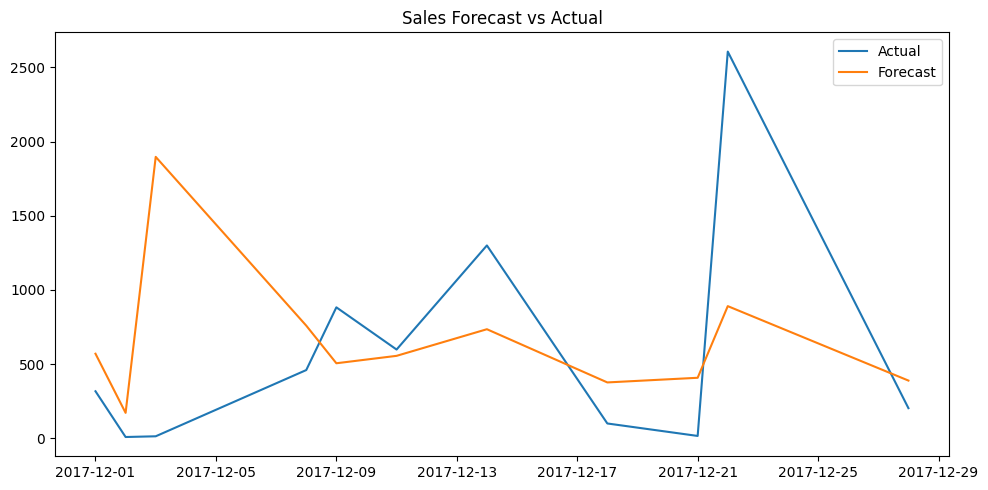

In [9]:
# 7. PLOT ONE STORE-ITEM SO WE CAN EYEBALL THE FORECAST
sample = df[(~train_mask) & (df['store'] == df['store'].iloc[0]) & (df['item'] == df['item'].iloc[0])].copy()
sample['pred'] = model.predict(sample[features])
plt.figure(figsize=(10, 5))
plt.plot(sample['date'], sample['sales'], label='Actual')
plt.plot(sample['date'], sample['pred'], label='Forecast')
plt.legend()
plt.title('Sales Forecast vs Actual')
plt.tight_layout()
plt.savefig('forecast_vs_actual.png')
plt.show()

### Step 8: Save Results

In [10]:
# 8. SAVE RESULTS
results = df[~train_mask][['date', 'store', 'item', 'sales']].copy()
results['forecast'] = preds
results.to_csv('sales_forecast_results.csv', index=False)